<a id="top"></a>


# Week 10 extension — train + evaluate (notebook 10d)

This notebook merges the **training** half (Week 10's Tasks 60–66, formerly
in `10d_extend_and_train.ipynb`) and the **evaluation** half (Tasks 67–70,
formerly in `10e_diffusion_NLL_ablations.ipynb`) into a single Colab-friendly
file. Each Colab session is isolated, so doing both halves in one notebook
means a fresh runtime can pick up where you left off without re-running
setup twice and without risking the `EXPERIMENTS` dict drifting between the
two halves.

## How to use this notebook

There is **one flag at the top** that determines what the notebook does:

- `MODE = "train"` — runs the data-augmentation cells (Tasks 60–63), the
  experiment-menu setup (Tasks 64–65), the training loop (Task 66), and the
  visual sanity check. The training loop is **idempotent**: it skips any
  experiment whose `ckpt_<name>.ckpt` already exists. Run the notebook many
  times with one new entry enabled in `ENABLED_EXPERIMENTS` per session.
- `MODE = "eval"` — skips training, jumps into the NLL ablation pipeline
  (Tasks 67–69), and scores every `ckpt_E*.ckpt` it finds in this directory.

**Recipe:** run with `MODE = "train"` repeatedly (one new experiment per
session) until you have all the checkpoints you want, then flip to
`MODE = "eval"` and run the notebook once to score them.

[**Jump to experiments**](#design_experiments)

[**↓ Jump to evaluation (Tasks 67–70)**](#eval-mode)

> The **test split is reserved for the PI**. Every data-loading cell in this
> notebook filters to `split in {"train", "val"}`. Do not change that.


In [190]:
MODE = "eval"   # set to "eval" once you have ckpt_E*.ckpt files to score

assert MODE in ("train", "eval"), f"MODE must be 'train' or 'eval', got {MODE!r}"
TRAIN_MODE = (MODE == "train")
EVAL_MODE  = (MODE == "eval")
print(f"MODE = {MODE!r}  (TRAIN_MODE={TRAIN_MODE}, EVAL_MODE={EVAL_MODE})")

MODE = 'eval'  (TRAIN_MODE=False, EVAL_MODE=True)


In [191]:
# Standard Week 10 setup: locate the repo, install if missing.

import os, subprocess, sys

# Keep this path if working in Colab
# repo_path = "/content/butterflai"

# Use this path if working locally
repo_path = "../../"

if not os.path.isdir(repo_path):
    subprocess.run(["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path], check=True)
else:
    try:
        subprocess.run(["git", "-C", repo_path, "pull"], check=True)
    except subprocess.CalledProcessError as e:
        print(f"git pull skipped: {e}")
sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


Already up to date.
  Installing from /home/russell/ButterflAI/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Local
   Device   : cuda
   Seed     : 42


{'in_colab': False,
 'device': device(type='cuda'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

In [192]:
%load_ext autoreload
%autoreload 2

import os, sys, glob, json, importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from scipy.stats import norm as sp_norm
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import repeat

import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger, CSVLogger
import wandb


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [193]:
# Bootstrap sys.path and locate artifacts.
import os, sys

for _p in [os.path.abspath(os.path.join(repo_path, "weeks", "week_10")),
           os.path.abspath(os.path.join(repo_path, "weeks", "week_09"))]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

from conditioned_infrastructure import find_week10_artifacts
# parquet_v2 is built fresh in Part A every run; raw CSV is needed by the
# eval phase (Task 67 Part 1). Both are listed as required so a missing
# raw CSV fails loudly at setup time rather than at Task 67.
paths = find_week10_artifacts(extra_required=[
    "data/composite_sunspot_groups_peak_area.csv",
])
print(f"using conditioned_infrastructure from: {paths['conditioned_py']}")

from unconditioned_infrastructure import make_cosine_schedule
from conditioned_infrastructure import (
    ExtendedConditionalResidualDataset,
    ExtendedConditionalDiffusionLightning,
    train_experiment,
    load_trained_experiment,
    sample_conditional_extended,
    build_model,
    block_cond_concat,
    k_run_combined,
    discover_experiment_checkpoints,
)
from butterflAI_model import ButterflAIModel

_WEEK10_DIR = paths["week10_dir"]
PARQUET_V2  = os.path.join(_WEEK10_DIR, "diffusion_windows_v2.parquet")
CKPT_DIR    = _WEEK10_DIR

classical   = ButterflAIModel(paths["classical_weights"])

LAT_BINS    = np.linspace(0, 45, 16)
BIN_WIDTH   = 3.0
BIN_CENTERS = 0.5 * (LAT_BINS[:-1] + LAT_BINS[1:])

T = 200
alpha_np, sigma_np, _ = make_cosine_schedule(T=T, s=0.008)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the v1 parquet — we extend it but never modify it.
# Test split is reserved for the PI.
windows_v1 = pd.read_parquet(paths["parquet_v1"])
windows_v1 = windows_v1.loc[windows_v1["split"].isin(["train", "val"])].reset_index(drop=True)
print(f"v1 parquet (train+val only): {len(windows_v1)} rows")
print(f"  splits: {windows_v1['split'].value_counts().sort_index().to_dict()}")
print(f"  cycles: {sorted(windows_v1['cycle'].unique())}")
print(f"v2 parquet target: {PARQUET_V2}")
print(f"device           : {device}")


using conditioned_infrastructure from: /home/russell/ButterflAI/butterflai/weeks/week_10/conditioned_infrastructure.py
v1 parquet (train+val only): 287 rows
  splits: {'train': 232, 'val': 55}
  cycles: [np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
v2 parquet target: /home/russell/ButterflAI/butterflai/weeks/week_10/diffusion_windows_v2.parquet
device           : cuda


---
## Part A — Build the augmented parquet

We're going to add three families of new conditioning columns to the
v1 parquet:

1. **Cycle and hemisphere identifiers** — a normalized cycle number and
   a north/south indicator.
2. **Opposite-hemisphere summaries** — for each window, the
   *contemporaneous* opposite-hemisphere activity. This is not leakage:
   contemporaneous opposite-hemisphere activity is operationally
   observable (an operational forecaster on the day of the same window
   would have it).
3. **Smoothed-area trajectory** — the past `K` windows of `area_smoothed`
   for the same hemicycle, as a short autoregressive history.

The build cells **rewrite `diffusion_windows_v2.parquet` every run**. We
deliberately do *not* gate on file existence — if you change how a
column is computed and don't see the change downstream, the most
common explanation is "the file was cached." We avoid that failure
mode by always rewriting.


---
## Task 60 — Cycle and hemisphere identifiers

Add two new columns to the dataframe:

- `cycle_norm`: cycle number rescaled to roughly `[-1, +1]` over the
  train range. The point of normalization is not to be exactly in
  `[-1, +1]` — it's to put the input on the same numerical scale as the
  other conditioning vectors so the network doesn't have to learn an
  outsized weight for it.
- `hemi_id`: `+1` for north, `-1` for south.

Both are cheap and let downstream experiments test whether
*structural* per-cycle / per-hemisphere effects survive once amplitude
is controlled for.


In [194]:
# Task 60 — add cycle_norm and hemi_id.

windows_aug = windows_v1.copy()

# TODO: compute cycle_norm. Use train-set cycle range so this is well
# defined for both splits. Aim for the train cycle range to map roughly
# onto [-1, +1].
_train_cycles = windows_aug.loc[windows_aug["split"] == "train", "cycle"]
_cmin, _cmax  = _train_cycles.min(), _train_cycles.max()
windows_aug["cycle_norm"] = 2.0 * (windows_aug["cycle"] - _cmin) / (_cmax - _cmin) - 1.0

# TODO: compute hemi_id. +1 north, -1 south.
windows_aug["hemi_id"] = np.where(windows_aug["hemisphere"] == "north", 1.0, -1.0)

print("cycle_norm range:", windows_aug["cycle_norm"].min(), windows_aug["cycle_norm"].max())
print("hemi_id values  :", windows_aug["hemi_id"].unique())


cycle_norm range: -1.0 1.0
hemi_id values  : [-1.  1.]


---
## Task 61 — Opposite-hemisphere conditioning

For each window in hemisphere *h* at time `tau_center`, attach the
contemporaneous opposite-hemisphere activity summary:

- `opp_area_smoothed` — opposite hemisphere's `area_smoothed`
- `opp_mu_universal`  — opposite hemisphere's `mu_universal`
- `opp_amplitude`     — opposite hemisphere's `amplitude`
- `opp_valid`         — 1 if a matching opposite row was found at the
  same `(cycle, tau_center)`, else 0.

When `opp_valid == 0` (no matching opposite row), impute with the
**train-set mean** of each opposite-* column. This way the network always
sees a defined input; downstream you can decide whether to gate on the
mask.

**Implementation hint:** the cleanest way is a self-merge of the
dataframe with itself: produce a "right side" with `hemisphere`
flipped and renamed columns, then merge on `(cycle, tau_center)`.


In [195]:
# Task 61 — attach contemporaneous opposite-hemisphere summaries.

# TODO: build a "right side" dataframe with hemisphere flipped and the
#       three columns we want renamed with the "opp_" prefix.
_flip = {"north": "south", "south": "north"}
_right = (windows_aug
          .loc[:, ["cycle", "tau_center", "hemisphere",
                   "area_smoothed", "mu_universal", "amplitude"]]
          .assign(opp_of_hemisphere=lambda d: d["hemisphere"].map(_flip))
          .drop(columns=["hemisphere"])
          .rename(columns={
              "area_smoothed": "opp_area_smoothed",
              "mu_universal":  "opp_mu_universal",
              "amplitude":     "opp_amplitude",
              "opp_of_hemisphere": "hemisphere",
          }))

# Drop any previous opp_* columns if they exist (in case we're re-running this cell).
_opp_cols = ["opp_area_smoothed", "opp_mu_universal", "opp_amplitude", "opp_valid"]
for _c in _opp_cols:
    if _c in windows_aug.columns:
        windows_aug = windows_aug.drop(columns=[_c])

# TODO: merge on (cycle, tau_center) so each row gets the
#       opposite-side row at the same time/cycle.
windows_aug = windows_aug.merge(
    _right, on=["cycle", "tau_center"],
    how="left", suffixes=("", "_right"), indicator="_opp_match",
)
# Filter to keep only opposite-hemisphere matches, then drop the duplicate hemisphere.
mask_valid = windows_aug["hemisphere"] != windows_aug["hemisphere_right"]
windows_aug.loc[~mask_valid, ["opp_area_smoothed", "opp_mu_universal", "opp_amplitude"]] = np.nan
windows_aug["opp_valid"] = mask_valid.astype(np.float32)
windows_aug = windows_aug.drop(columns=["_opp_match", "hemisphere_right"])

# TODO: impute missing opp_* values with train-set means.
_opp_cols_imp = ["opp_area_smoothed", "opp_mu_universal", "opp_amplitude"]
_train_mask = (windows_aug["split"] == "train") & (windows_aug["opp_valid"] == 1.0)
for _c in _opp_cols_imp:
    _mean = windows_aug.loc[_train_mask, _c].mean()
    windows_aug[_c] = windows_aug[_c].fillna(_mean)

print(f"opp_valid coverage: {windows_aug['opp_valid'].mean():.3f}")
print(f"opp_area_smoothed (train, valid): "
      f"mean={windows_aug.loc[_train_mask, 'opp_area_smoothed'].mean():.3f}, "
      f"std={windows_aug.loc[_train_mask, 'opp_area_smoothed'].std():.3f}")

opp_valid coverage: 1.000
opp_area_smoothed (train, valid): mean=86.796, std=43.082


---
## Task 62 — Smoothed-area trajectory (cycle history)

For each window, attach the previous `K` values of `area_smoothed`
from the same hemicycle (same `cycle` AND same `hemisphere`), ordered
chronologically by `tau_center`. Columns: `area_lag1`, `area_lag2`, …,
`area_lagK`.

`area_lag1` is the *previous* window's smoothed area; `area_lagK` is
the one K steps back. Boundary windows (near the start of a hemicycle,
where fewer than K prior windows exist) get train-set-mean imputation
and a `traj_valid` column set to 0 for that row.

The point: cycle *history* is information that amplitude alone misses.
A window 6 months into a strong cycle and a window 6 months from the
end of a strong cycle have similar amplitude but very different
trajectory.

**Implementation hint:** sort within each hemicycle by `tau_center`,
then shift the `area_smoothed` series by 1, 2, …, K.


In [196]:
# Task 62 — attach the smoothed-area trajectory (K lagged values).

K_LAGS = 4

# TODO: within each (cycle, hemisphere) group, sort by tau_center and
#       produce K columns of shifted area_smoothed.
_sorted = windows_aug.sort_values(["cycle", "hemisphere", "tau_center"])

_lag_cols = [f"area_lag{k}" for k in range(1, K_LAGS + 1)]
for k, col in enumerate(_lag_cols, start=1):
    _sorted[col] = _sorted.groupby(["cycle", "hemisphere"])["area_smoothed"].shift(k)

# A row is traj_valid iff *all* K lags exist.
_sorted["traj_valid"] = (~_sorted[_lag_cols].isna().any(axis=1)).astype(np.float32)

# TODO: impute boundary NaNs with train-set means.
_train_mask = (_sorted["split"] == "train") & (_sorted["traj_valid"] == 1.0)
for col in _lag_cols:
    _mean = _sorted.loc[_train_mask, col].mean()
    _sorted[col] = _sorted[col].fillna(_mean)

windows_aug = _sorted.sort_index()  # restore original row order

print(f"traj_valid coverage: {windows_aug['traj_valid'].mean():.3f}")
print(f"lag columns: {_lag_cols}")


traj_valid coverage: 0.721
lag columns: ['area_lag1', 'area_lag2', 'area_lag3', 'area_lag4']


---
## Task 63 — Write `diffusion_windows_v2.parquet` and sanity-check

Write the augmented dataframe. Sanity checks before we trust it
downstream:

- Row count unchanged from v1 (we did not gain or lose any windows).
- Every original v1 column is preserved bit-for-bit.
- New cond columns are finite **wherever the validity mask says they
  should be**.
- `split` column is unchanged.


In [197]:
# Task 63 — write v2 + sanity checks.

# Sanity 1: row count.
assert len(windows_aug) == len(windows_v1), \
    f"row count drifted: {len(windows_aug)} vs v1 {len(windows_v1)}"

# Sanity 2: every v1 column preserved bit-for-bit.
for c in windows_v1.columns:
    assert c in windows_aug.columns, f"missing v1 column {c}"
    if windows_v1[c].dtype.kind in "fc":
        assert np.allclose(windows_v1[c].to_numpy(),
                           windows_aug[c].to_numpy(), equal_nan=True), c
    else:
        assert (windows_v1[c].astype(str).to_numpy()
                == windows_aug[c].astype(str).to_numpy()).all(), c

# Sanity 3: new columns finite where the validity masks allow.
NEW_COND_COLS = ["cycle_norm", "hemi_id",
                 "opp_area_smoothed", "opp_mu_universal", "opp_amplitude",
                 *[f"area_lag{k}" for k in range(1, K_LAGS + 1)]]
for c in NEW_COND_COLS:
    assert windows_aug[c].notna().all(), f"NaN remains in {c}"

# Sanity 4: split column unchanged.
assert (windows_aug["split"].to_numpy() == windows_v1["split"].to_numpy()).all()

# Always rewrite. Never cache.
windows_aug.to_parquet(PARQUET_V2, index=False)
print(f"wrote {PARQUET_V2}  ({len(windows_aug)} rows, {len(windows_aug.columns)} cols)")
print(f"new cond columns: {NEW_COND_COLS}")


wrote /home/russell/ButterflAI/butterflai/weeks/week_10/diffusion_windows_v2.parquet  (287 rows, 49 cols)
new cond columns: ['cycle_norm', 'hemi_id', 'opp_area_smoothed', 'opp_mu_universal', 'opp_amplitude', 'area_lag1', 'area_lag2', 'area_lag3', 'area_lag4']


---
## Part B — wandb setup and the experiment menu

### Task 64 — Per-student wandb project

Each student gets their **own** wandb project. Replace the placeholder
strings below with your handle. Every training run in this notebook
logs to that project with the experiment ID as the run name; you can
compare all your variants on a single dashboard.

If wandb is unavailable in your environment, training will fall back to
a local CSV logger automatically. The assertion guard runs in both
modes so eval mode also tells you if you forgot to personalize the
project name.


In [198]:
# Task 64 — wandb identity. EDIT THESE.

WANDB_PROJECT = "butterflai-w10ext-rhankey"
# WANDB_ENTITY  = "hankeyrj"      # set to None if you don't use teams
WANDB_ENTITY  = None      # set to None if you don't use teams

# assert "your-handle" not in WANDB_PROJECT, \
#     "Set WANDB_PROJECT to your own project name before training."


<a id="design_experiments"></a>

### Task 65 — Design your own experiments

The Week 10 baseline (E0) reproduces the existing conditional
diffusion on the v2 parquet — no new knobs. Everything beyond it is
your call. Each variant you propose should change **one knob** from
the previous run and answer **one question**.

The knobs available are:

- **Cond groups** (`groups` / `consumed_keys`): `base`, plus any of
  `cyclehemi`, `opp`, `traj`.
- **Architecture** (`arch`): `concat` or `film`.
- **Classifier-free guidance**: `cond_dropout_p=0.1` at training time;
  10e sweeps the guidance weight at sampling.
- **Fourier lifting**: `fourier=True` lifts cond scalars via sin/cos.

The menu below escalates roughly by effort-per-insight. Pick what's
interesting, add a new entry to `EXPERIMENTS`, and progress one
variant per session.

**Level 1 — same cond, change the channel.**
Add one of the new cond groups (`cyclehemi`, `opp`, `traj`) to E0's
`consumed_keys`. *Does the diffusion's val NLL drop when given more
information, with the architecture held fixed?*

**Level 2 — same information, change the mechanism.**
Switch `arch` from `concat` to `film` while keeping `cond_base` only.
*Does the modulation mechanism alone close the gap with classical?*

**Level 3 — best information × best mechanism.**
Combine your best Level 1 cond set with FiLM. *Is the combined gain
additive, or did Level 2 already capture it?*

**Level 4 — guidance.**
Set `cond_dropout_p=0.1` and train. Sampling guidance is swept in 10e.
*Can sharpening the conditional density buy you margin over Level 3?*

**Level 5 — Fourier lifting.**
Set `fourier=True`. *Does sin/cos lifting of the cond scalars help the
network represent boundaries?*

You can go further — bump `hidden_dim` / `n_layers`, raise `K_LAGS`
back in Task 62, pair lagged opposite-hemisphere with trajectory, or
anything else you can defend. Different students should diverge here;
results pool in 10e.

[**Go back to top**](#top)

In [ ]:
# Task 65 — experiment specs. Start with the baseline; add new entries
# below as you escalate (see the markdown above). See
# conditioned_infrastructure.build_model for the recognized keys.

_BASE_TEMPLATE = {
    "arch":           "concat",
    "consumed_keys":  ["cond_base"],
    "groups":         ["base"],
    "hidden_dim":     128,
    "n_layers":       3,
    "fourier":        False,
    "cond_dropout_p": 0.0,
    "max_epochs":     20000,
    "lr":             1e-3,
    "batch_size":     64,
}

def _spec(**overrides):
    d = dict(_BASE_TEMPLATE); d.update(overrides); return d

EXPERIMENTS = {
    "E0": _spec(),   # baseline — same 4-D cond on the v2 parquet
    # Add your own variants below, e.g.:
    #   "E1": _spec(consumed_keys=["cond_base", "cond_opp"],
    #               groups=["base", "opp"]),
    #   "E2": _spec(arch="film"),
    "E1": _spec(consumed_keys=["cond_base", "cond_cyclehemi"], groups=["base", "cyclehemi"]),
    "E2": _spec(consumed_keys=["cond_base", "cond_opp"], groups=["base", "opp"], max_epochs=3000),
    "E3": _spec(consumed_keys=["cond_base", "cond_traj"], groups=["base", "traj"], max_epochs=3000),
    "E4": _spec(arch="film", max_epochs=3000),
    "E5": _spec(fourier=True, max_epochs=3000),
    "E6": _spec(cond_dropout_p=0.1, max_epochs=3000),
    "E7": _spec(batch_size=128, max_epochs=3000),
    "E8": _spec(hidden_dim=256, max_epochs=3000),
    "E9": _spec(n_layers=5, max_epochs=3000),
    "E10": _spec(hidden_dim=256, n_layers=5, max_epochs=3000),
    "E11": _spec(consumed_keys=["cond_base", "cond_opp"], groups=["base", "opp"]),
    "E12": _spec(consumed_keys=["cond_base", "cond_traj"], groups=["base", "traj"]),
    "E13": _spec(arch="film"),
    "E14": _spec(fourier=True),
    "E15": _spec(cond_dropout_p=0.1),
    "E16": _spec(batch_size=128),
    "E17": _spec(hidden_dim=256),
    "E18": _spec(n_layers=5),
    "E19": _spec(hidden_dim=256, n_layers=5),
    "E20": _spec(cond_dropout_p=0.1, fourier=True),
    "E21": _spec(cond_dropout_p=0.5),
    "E22": _spec(arch="film", cond_dropout_p=0.1),
    "E23": _spec(arch="film", fourier=True),
    "E24": _spec(arch="film", cond_dropout_p=0.1, fourier=True),
    "E25": _spec(arch="film", cond_dropout_p=0.5),
    "E26": _spec(arch="film", cond_dropout_p=0.5, fourier=True),
}

for name, cfg in EXPERIMENTS.items():
    print(f"{name}: arch={cfg['arch']:6s}  consumed={cfg['consumed_keys']}  "
          f"fourier={cfg['fourier']}  cond_dropout_p={cfg['cond_dropout_p']}")

E0: arch=concat  consumed=['cond_base']  fourier=False  cond_dropout_p=0.0
E1: arch=concat  consumed=['cond_base', 'cond_cyclehemi']  fourier=False  cond_dropout_p=0.0
E2: arch=concat  consumed=['cond_base', 'cond_opp']  fourier=False  cond_dropout_p=0.0
E3: arch=concat  consumed=['cond_base', 'cond_traj']  fourier=False  cond_dropout_p=0.0
E4: arch=film    consumed=['cond_base']  fourier=False  cond_dropout_p=0.0
E5: arch=concat  consumed=['cond_base']  fourier=True  cond_dropout_p=0.0
E6: arch=concat  consumed=['cond_base']  fourier=False  cond_dropout_p=0.1
E7: arch=concat  consumed=['cond_base']  fourier=False  cond_dropout_p=0.0
E8: arch=concat  consumed=['cond_base']  fourier=False  cond_dropout_p=0.0
E9: arch=concat  consumed=['cond_base']  fourier=False  cond_dropout_p=0.0
E10: arch=concat  consumed=['cond_base']  fourier=False  cond_dropout_p=0.0
E11: arch=concat  consumed=['cond_base', 'cond_opp']  fourier=False  cond_dropout_p=0.0
E12: arch=concat  consumed=['cond_base', 'co

---
## Part C — Disciplined sweep (TRAIN MODE)

### Task 66 — Enable a subset and train

Discipline:

- Add at most **one new experiment per session** beyond the baseline.
  Two-knob-at-a-time changes make the 10e diff impossible to read.
- Each enabled experiment logs to your wandb project under its name
  (`E0`, `E1`, …); compare them on a single dashboard.
- The loop skips checkpoints that already exist on disk, so re-running
  the notebook does not retrain unless you delete the file.

*The cells below only execute when `MODE == "train"`.*


In [200]:
if not TRAIN_MODE:
    print("Skipping Task 66 training loop (MODE=eval). Switch MODE to \"train\" to run this cell.")
else:
    # Task 66 — enable, then train. EDIT THIS LIST.

    ENABLED_EXPERIMENTS = ["E20", "E21", "E22", "E23", "E24"]   # add one experiment per session

    for _name in ENABLED_EXPERIMENTS:
        if _name not in EXPERIMENTS:
            raise KeyError(f"unknown experiment {_name!r}; defined: {list(EXPERIMENTS)}")
        train_experiment(
            name=_name, cfg=EXPERIMENTS[_name],
            windows_aug=windows_aug, ckpt_dir=CKPT_DIR,
            wandb_project=WANDB_PROJECT, wandb_entity=WANDB_ENTITY,
            alpha_np=alpha_np, sigma_np=sigma_np, T=T,
            bin_centers=BIN_CENTERS, bin_width=BIN_WIDTH,
        )


Skipping Task 66 training loop (MODE=eval). Switch MODE to "train" to run this cell.


---
## Part D — Visual sanity check on the most recent training

Sample a small batch of validation conditioning vectors and overlay
the diffusion's generated residuals against the ground truth. This is
a "did training collapse?" check — not a quantitative comparison. The
real evaluation lives in the EVAL MODE section below.


In [201]:
if not TRAIN_MODE:
    print("Skipping Part D visual sanity check (MODE=eval). Switch MODE to \"train\" to run this cell.")
else:
    # Part D — quick overlay for the most recently trained checkpoint.

    if not ENABLED_EXPERIMENTS:
        print("No experiments were trained this session — nothing to visualize.")
    else:
        _name = ENABLED_EXPERIMENTS[-1]
        _cfg  = EXPERIMENTS[_name]
        lit, _, val_ds, _ = load_trained_experiment(
            _name, _cfg, windows_aug, CKPT_DIR, alpha_np, sigma_np,
        )

        n_show = 4
        cond_concat = torch.cat(
            [torch.stack([val_ds[i][k] for i in range(n_show)])
             for k in _cfg["consumed_keys"]],
            dim=-1,
        )
        truth = torch.stack([val_ds[i]["r_clean"] for i in range(n_show)]).numpy()
        truth_phys = truth * val_ds.bin_stds.numpy() + val_ds.bin_means.numpy()
        samples = sample_conditional_extended(lit, cond_concat, guidance_w=0.0).cpu().numpy()

        fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 3.2), sharey=True)
        for i, ax in enumerate(axes):
            w = BIN_WIDTH * 0.4
            ax.bar(BIN_CENTERS - w / 2, truth_phys[i], width=w, color="C0", label="truth")
            ax.bar(BIN_CENTERS + w / 2, samples[i],    width=w, color="C2", label="sampled")
            ax.axhline(0, color="k", lw=0.4)
            ax.set_title(f"val window {i}")
            ax.set_xlabel("|latitude| (°)")
        axes[0].set_ylabel("residual"); axes[0].legend()
        fig.suptitle(f"{_name}: visual sanity check")
        fig.tight_layout(); plt.show()


Skipping Part D visual sanity check (MODE=eval). Switch MODE to "train" to run this cell.


<a id="eval-mode"></a>

---
# Evaluation mode — NLL ablations across all experiments (Tasks 67–70)

This is the evaluation half of the Week 10 extension. It scores every
checkpoint produced by train mode (`ckpt_E*.ckpt` in this directory)
against the same **hard-gated NLL** metric used in 10c, and adds a
critical new diagnostic: an **oracle MLP** that maps each experiment's
cond vector directly to per-bin Gaussian residual parameters. The
oracle's NLL is an *upper bound* on what any model can extract from a
given cond set:

- Diffusion ≪ oracle  →  architecture is the bottleneck (try FiLM, CFG, Fourier).
- Oracle ≈ classical  →  the cond set itself doesn't help; try a different
  cond group or stop running that variant.

This is what makes the ablation scientifically honest: without an
oracle, a flat NLL across experiments could mean *either* "more cond
doesn't help" *or* "the architecture can't extract the new cond's
information" — two completely different fixes.

*The code cells below only execute when `MODE == "eval"`.*


---
## Task 67 — Build per-window evaluation blocks

Re-window the raw CSV the same way 10c does (per-window, 6-monthly,
≥ 20 obs per window) and tag each window with its v2 parquet row's
*entire* cond superset — every group, normalized later per-experiment
using the corresponding checkpoint's `cond_<g>_means` / `cond_<g>_stds`
buffers. We work with **per-window blocks only** in 10e — that is the
granularity at which the diffusion model is native, and the granularity
where any improvement over Week 10 will be most visible.

[**Go back to top**](#top)

In [202]:
if not EVAL_MODE:
    print("Skipping Task 67 Part 1 (per-window blocks) (MODE=train). Switch MODE to \"eval\" once you have ckpt_E*.ckpt files.")
else:
    # Task 67 — per-window blocks tagged with their v2 cond superset.
    #
    # Goal: rebuild per-window evaluation blocks for every (cycle, hemisphere)
    # in train+val, identical to the per-window construction in 10c, and tag
    # each block with the *raw* (unnormalized) vector from each cond group in
    # the v2 parquet. Downstream cells normalize per-experiment using each
    # checkpoint's buffers via `block_cond_concat`.
    #
    # Reference: 10c uses a 6-monthly window with min 20 obs per window.
    #
    # Expected outputs:
    #   GROUP_COLS  — dict mapping group name ("base", "cyclehemi", "opp",
    #                 "traj") → list of column names in windows_v2.
    #                 Resolve "traj" dynamically from columns starting with
    #                 "area_lag".
    #   hemicycles  — list of dicts, one per hemicycle, carrying a "blocks"
    #                 list. Each block dict must include:
    #                   "center_decimal", "tau", "lats" (np.ndarray of |lat|),
    #                   "groups_raw" (dict group → raw float32 vector).
    #                 Each hemicycle dict must include "cycle", "hemisphere",
    #                 "amplitude", "t0", "split", "blocks".

    raw_df = pd.read_csv(paths["raw_csv"])
    
    # Parse dates, compute abs_lat, derive hemisphere, drop missing CYCLE.
    raw_df["date"]       = pd.to_datetime(raw_df[["year", "month", "day"]])
    raw_df["abs_lat"]    = raw_df["latitude"].abs()
    raw_df["hemisphere"] = np.where(raw_df["latitude"] >= 0, "north", "south")
    raw_df = raw_df.dropna(subset=["CYCLE"]).copy()
    raw_df["CYCLE"]      = raw_df["CYCLE"].astype(int)
    raw_df["year"]       = raw_df["date"].dt.year

    # Define GROUP_COLS (mirror ExtendedConditionalResidualDataset.GROUP_COLS).
    # "traj" is resolved dynamically from area_lag* columns.
    _traj_cols = sorted(
        [c for c in windows_aug.columns if c.startswith("area_lag")],
        key=lambda c: int(c.replace("area_lag", "")),
    )
    GROUP_COLS = {
        "base":       ["area_smoothed", "mu_universal", "model_sigma", "amplitude"],
        "cyclehemi":  ["cycle_norm", "hemi_id"],
        "opp":        ["opp_area_smoothed", "opp_mu_universal", "opp_amplitude"],
        "traj":       _traj_cols,
    }
    
    # Pull (cycle, hemisphere) → split from the parquet.
    hc_split = (windows_aug.groupby(["cycle", "hemisphere"])["split"]
                           .agg(lambda s: s.iloc[0]).to_dict())
    # Amplitude by cycle/hemi — classical sigma input.
    amp_lookup = (windows_aug.groupby(["cycle", "hemisphere"])["amplitude"]
                             .agg("first").to_dict())

    # Build year_center for the parquet rows (needed for lookup keying).
    _t0_by_hc = {(int(c), str(h)): float(classical.lookup_t0(int(c), h))
                 for (c, h) in classical.known_hemicycles()}
    _wdf = windows_aug.copy()
    _wdf = _wdf[_wdf.apply(lambda r: (int(r["cycle"]), str(r["hemisphere"])) in _t0_by_hc, axis=1)]
    _wdf["year_center"] = _wdf.apply(
        lambda r: float(r["tau_center"]) + _t0_by_hc[(int(r["cycle"]), str(r["hemisphere"]))],
        axis=1,
    )

    # Build a per-window cond lookup keyed by (cycle, hemisphere, year_center).
    # Each entry stores groups_raw — a dict mapping group name to raw float32 vector.
    groups_raw_lookup = {}
    for _, r in _wdf.iterrows():
        key = (int(r["cycle"]), str(r["hemisphere"]), float(r["year_center"]))
        groups_raw_dict = {}
        for group_name, cols in GROUP_COLS.items():
            group_raw = np.array([float(r[c]) for c in cols], dtype=np.float32)
            groups_raw_dict[group_name] = group_raw
        groups_raw_lookup[key] = groups_raw_dict

    def _lookup_groups_raw(cyc, hemi, c_dec, tol=1e-2):
        """Closest-center match in calendar-year units. Returns dict of
        group_name -> raw vector, or a NaN-filled dict if no parquet row
        is within tolerance."""
        best_gr, best_d = None, tol
        for (c2, h2, yc), gr in groups_raw_lookup.items():
            if c2 != cyc or h2 != hemi:
                continue
            d = abs(float(yc) - c_dec)
            if d <= best_d:
                best_gr, best_d = gr, d
        if best_gr is None:
            # No match found — return NaN-filled dict.
            best_gr = {g: np.full(len(cols), np.nan, dtype=np.float32)
                      for g, cols in GROUP_COLS.items()}
        return best_gr

    def build_per_window_hc(cyc, hemi, df_hc):
        """Build per-window blocks for one hemicycle."""
        if len(df_hc) == 0:
            return []
        y0, y1 = df_hc["date"].min().year, df_hc["date"].max().year + 1
        bounds = sorted({pd.Timestamp(y, m, 1)
                         for y in range(y0, y1 + 1) for m in (1, 7)})
        blocks = []
        for ws, we in zip(bounds[:-1], bounds[1:]):
            mask = (df_hc["date"] >= ws) & (df_hc["date"] < we)
            dfw = df_hc.loc[mask]
            if len(dfw) < 20:
                continue
            c_ts  = ws + (we - ws) / 2
            c_dec = c_ts.year + c_ts.dayofyear / 365.25
            groups_raw = _lookup_groups_raw(cyc, hemi, c_dec)
            # Check if any group has all NaN — if so, skip.
            if any(np.all(np.isnan(gr)) for gr in groups_raw.values()):
                continue
            blocks.append({
                "center_decimal": float(c_dec),
                "tau":  float(classical.to_tau(cyc, hemi, c_dec)),
                "lats": dfw["abs_lat"].to_numpy(np.float32),
                "groups_raw": groups_raw,
            })
        return blocks

    # Assemble hemicycles.
    hemicycles = []
    for (cyc, hemi), split in hc_split.items():
        if split not in ("train", "val"):
            continue
        try:
            t0 = float(classical.lookup_t0(cyc, hemi))
        except KeyError:
            continue
        A = float(amp_lookup[(cyc, hemi)])
        dfh = raw_df[(raw_df["CYCLE"] == int(cyc)) & (raw_df["hemisphere"] == hemi)]
        blocks = build_per_window_hc(cyc, hemi, dfh)
        if not blocks:
            continue
        hemicycles.append({
            "cycle": int(cyc),
            "hemisphere": hemi,
            "amplitude": A,
            "t0": t0,
            "split": split,
            "blocks": blocks,
        })

    assert len(hemicycles) > 0, "rebuild the per-window blocks before continuing"
    assert all("groups_raw" in blk for hc in hemicycles for blk in hc["blocks"]), \
        "every block needs a groups_raw dict"
    print(f"per-window blocks built: {sum(len(hc['blocks']) for hc in hemicycles)}")
    print(f"hemicycles included    : {len(hemicycles)}")
    print(f"GROUP_COLS keys        : {list(GROUP_COLS.keys())}")

per-window blocks built: 287
hemicycles included    : 20
GROUP_COLS keys        : ['base', 'cyclehemi', 'opp', 'traj']


---
## Task 67 (cont) — NLL primitives, same as 10c

These are byte-identical to the primitives in 10c. Re-stated here so
10e can be run standalone (without executing 10c first).


In [203]:
if not EVAL_MODE:
    print("Skipping Task 67 Parts 2-3 (hard NLL primitives) (MODE=train). Switch MODE to \"eval\" once you have ckpt_E*.ckpt files.")
else:
    # Task 67 — hard NLL primitives. Port from 10c (or import them if you've
    # factored them out). The two callables you need are:
    #
    #   hard_nll_classical(model, hcs) -> (nll, detail)
    #   hard_nll_combined (model, hcs, residuals_by_block, eps=1e-6)
    #                                                  -> (nll, detail)
    #
    # 10c defines both; they are byte-identical here. Once defined, the
    # print below should report a classical baseline near 10c's val number.

    # TODO: define hard_nll_classical and hard_nll_combined.

    def hard_nll_classical(model, hcs):
        """Apply the classical Gaussian density to raw |latitude| values, hard-gated
        against `model.mu_0(amplitude)`. Returns (nll, details).
        """
        total, included, candidate = 0.0, 0, 0
        for hc in hcs:
            A    = hc["amplitude"]
            mu0A = float(model.mu_0(A))
            for blk in hc["blocks"]:
                candidate += 1
                mu = float(model.mu(blk["tau"]))
                if mu > mu0A:
                    continue
                sigma = float(model.sigma(mu, A))
                if sigma <= 0:
                    continue
                ll = sp_norm.logpdf(blk["lats"], loc=mu, scale=sigma).mean()
                if not np.isfinite(ll):
                    continue
                total    -= ll
                included += 1
        nll = total / included if included > 0 else float("inf")
        return nll, {"included": included, "candidate": candidate,
                    "coverage": included / max(candidate, 1)}


    def hard_nll_combined(model, hcs, residuals_by_block, eps=1e-6):
        """Same as hard_nll_classical but the per-block density is the classical
        continuous Gaussian PLUS the per-bin sampled residual (in density units),
        floored at `eps` to keep log finite when the residual over-corrects.
        `residuals_by_block`: dict keyed by (cycle, hemi, center_decimal) → (15,) array.
        """
        total, included, candidate = 0.0, 0, 0
        n_floored, n_lats = 0, 0
        for hc in hcs:
            A    = hc["amplitude"]
            mu0A = float(model.mu_0(A))
            for blk in hc["blocks"]:
                candidate += 1
                mu = float(model.mu(blk["tau"]))
                if mu > mu0A:
                    continue
                sigma = float(model.sigma(mu, A))
                if sigma <= 0:
                    continue
                key = (hc["cycle"], hc["hemisphere"], blk["center_decimal"])
                if key not in residuals_by_block:
                    continue
                residual = residuals_by_block[key]                          # (15,) array

                lats   = blk["lats"]
                p_cl   = sp_norm.pdf(lats, loc=mu, scale=sigma)
                bin_ix = np.clip(np.floor(lats / BIN_WIDTH).astype(int), 0, 14)
                p_raw  = p_cl + residual[bin_ix]
                p_comb = np.maximum(eps, p_raw)
                n_floored += int((p_raw < eps).sum())
                n_lats    += len(lats)

                ll = np.log(p_comb).mean()
                if not np.isfinite(ll):
                    continue
                total    -= ll
                included += 1
        nll = total / included if included > 0 else float("inf")
        return nll, {"included": included, "candidate": candidate,
                    "coverage": included / max(candidate, 1),
                    "floor_fraction": n_floored / max(n_lats, 1)}

    val_hcs = [hc for hc in hemicycles if hc["split"] == "val"]
    nll_cl_val, det_cl_val = hard_nll_classical(classical, val_hcs)
    print(f"classical hard NLL (val): {nll_cl_val:.4f}  "
          f"(coverage {det_cl_val['coverage']:.3f})")


classical hard NLL (val): 3.2396  (coverage 1.000)


---
## Task 67 (cont) — Diagnostic oracle

For each experiment's cond set, fit a tiny MLP that maps the cond
vector directly to a 15-D Gaussian over the residual bins
(`mean`, `log_std`). The oracle's NLL is computed by sampling K
residuals from the per-block Gaussian and feeding them through
`hard_nll_combined` — the same harness used to score the diffusion.

What the oracle answers:

- **Diffusion ≪ oracle**  →  the diffusion isn't extracting the
  information that's already in the cond. Try a stronger architecture
  (FiLM, Fourier features, larger MLP).
- **Oracle ≈ classical**  →  the cond set itself doesn't carry enough
  information about the residual structure. Try a different cond
  group or stop adding to this one.

You implement this. The science (the tiny MLP, the Gaussian NLL
expression, the training loop, sampling from the predicted Gaussian)
is yours.

In [204]:
# # Task 67 — the oracle MLP. Students fill in the bodies below.

# class OracleMLP(nn.Module):
#     """Map a cond vector to per-bin Gaussian residual params (mean, log_std).

#     Output is 2 * 15 = 30 numbers per row: 15 means + 15 log-stds.
#     """
#     def __init__(self, cond_dim, hidden_dim=64):
#         super().__init__()
#         # TODO: build a 2–3 layer MLP with SiLU activations.
#         raise NotImplementedError("Task 67 — implement OracleMLP.__init__")

#     def forward(self, cond):
#         # TODO: return (mean, log_std), each shape (B, 15).
#         raise NotImplementedError("Task 67 — implement OracleMLP.forward")


# def gaussian_nll(r, mean, log_std):
#     """Per-row, per-bin Gaussian NLL of the *standardized* residual ``r``
#     under the predicted ``(mean, log_std)``. Return a scalar."""
#     # TODO: implement the closed-form Gaussian NLL.
#     raise NotImplementedError("Task 67 — implement gaussian_nll")


# def fit_oracle(cond_train, r_train, cond_val, r_val,
#                max_epochs=500, lr=1e-2, hidden_dim=64, seed=0):
#     """Fit OracleMLP on (cond_train, r_train); track val NLL each epoch
#     and return the module with the best val state restored, along with
#     the best val NLL. ``r_*`` are *standardized* residuals (15-D)."""
#     # TODO: instantiate OracleMLP, an Adam optimizer, and a training
#     #       loop with early stopping on best val gaussian_nll.
#     raise NotImplementedError("Task 67 — implement fit_oracle")

In [205]:
class OracleMLP(nn.Module):
    """Map a cond vector to per-bin Gaussian residual params (mean, log_std).

    Output is 2 * 15 = 30 numbers per row: 15 means + 15 log-stds.
    """

    def __init__(self, cond_dim: int, hidden_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 30),
        )

    def forward(self, cond: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        out = self.net(cond)
        # Split the 30 outputs into 15 means and 15 log_stds
        mean, log_std = out.chunk(2, dim=-1)
        return mean, log_std


def gaussian_nll(r: torch.Tensor, mean: torch.Tensor, log_std: torch.Tensor) -> torch.Tensor:
    """Per-row, per-bin Gaussian NLL of the *standardized* residual ``r``
    under the predicted ``(mean, log_std)``. Return a scalar.
    """
    # NLL = 0.5 * (log(2*pi) + log(sigma^2) + (r - mu)^2 / sigma^2)
    # log(sigma^2) = 2 * log_std
    return 0.5 * (torch.log(torch.as_tensor(2 * torch.pi)) + 2 * log_std + (r - mean)**2 * torch.exp(-2 * log_std)).mean()


def fit_oracle(
    cond_train: torch.Tensor,
    r_train: torch.Tensor,
    cond_val: torch.Tensor,
    r_val: torch.Tensor,
    max_epochs: int = 500,
    lr: float = 1e-2,
    hidden_dim: int = 64,
    seed: int = 0,
):
    """Fit OracleMLP on (cond_train, r_train); track val NLL each epoch
    and return the module with the best val state restored, along with
    the best val NLL. ``r_*`` are *standardized* residuals (15-D).
    """
    torch.manual_seed(seed)
    model = OracleMLP(cond_dim=cond_train.shape[1], hidden_dim=hidden_dim)
    model.to(cond_train.device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_nll = float("inf")
    best_state = None

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        m, ls = model(cond_train)
        loss = gaussian_nll(r_train, m, ls)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            mv, lsv = model(cond_val)
            val_nll = gaussian_nll(r_val, mv, lsv).item()

        if val_nll < best_val_nll:
            best_val_nll = val_nll
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_val_nll

---
## Task 68 — Score every checkpoint

For each discovered `ckpt_E*.ckpt`:

1. Build per-experiment cond tensors for every val block by
   concatenating the right groups in `consumed_keys` order, normalized
   with the **checkpoint's own** per-group buffers (so val data uses
   train-set normalization recovered from the saved model).
2. Run K = 100 conditional samples per block using
   `sample_conditional_extended`. For E6 (CFG), repeat the sampling at
   every guidance weight in `CFG_GUIDANCE_W` and keep them as separate
   rows.
3. Fit the oracle MLP on the same (cond, standardized residual) data
   and record its val NLL as the upper bound for this cond set.
4. Plug each of the K samples into `hard_nll_combined`; report mean
   and σ over K.


In [206]:
# # Task 68 — score every discovered checkpoint.

# K = 100   # K samples per val block; bump to 500 for tighter K-σ bars.

# # Guidance values to sweep when scoring a CFG-trained checkpoint.
# CFG_GUIDANCE_W = [1.0, 1.5, 2.0, 3.0]


# def score_checkpoint(name, cfg):
#     """Score one experiment.

#     The recipe:
#       1. Load the trained model + datasets via
#          `load_trained_experiment(name, cfg, windows_aug, _WEEK10_DIR,
#                                   alpha_np, sigma_np)`.
#       2. Build per-val-block cond tensors via
#          `block_cond_concat(val_hcs, lit, cfg, train_ds)`,
#          repeat each row K times, and sample residuals with
#          `sample_conditional_extended(lit, cond_K, guidance_w=w,
#                                        device=device)`.
#          If `cfg["cond_dropout_p"] > 0`, sweep every `w` in
#          `CFG_GUIDANCE_W` and emit one row per `w`; otherwise sample
#          once at `w = 0.0`.
#       3. Reshape samples to (N, K, 15) physical units; push them through
#          `k_run_combined(hard_nll_combined, classical, val_hcs, keys,
#                           samples_NK15)` to get K NLLs and floor
#          fractions.
#       4. Fit the oracle on the same cond set: build (cond, residual)
#          pairs for train and val blocks, standardize residuals with the
#          train-set bin stats, and call `fit_oracle`. Convert the
#          oracle's per-block Gaussian into K physical-unit samples and
#          push them through `k_run_combined` to get the oracle's
#          hard-NLL upper bound.

#     Returns a list of dicts with keys
#     {experiment, guidance_w, nll_mean, nll_std, floor,
#      oracle_nll_mean, oracle_nll_std, oracle_gauss, coverage}.
#     """
#     # TODO: implement the four steps above.
#     raise NotImplementedError("Task 68 — implement score_checkpoint")


In [207]:
# Task 68 — score every discovered checkpoint.

K = 100   # K samples per val block; bump to 500 for tighter K-σ bars.

# Guidance values to sweep when scoring a CFG-trained checkpoint.
CFG_GUIDANCE_W = [1.0, 1.5, 2.0, 3.0]


def score_checkpoint(name, cfg):
    """Score one experiment."""
    lit, train_ds, val_ds, _ = load_trained_experiment(
        name, cfg, windows_aug, _WEEK10_DIR, alpha_np, sigma_np
    )
    device = next(lit.parameters()).device

    keys, cond_val = block_cond_concat(val_hcs, lit, cfg, train_ds)
    K = 100
    cond_K = cond_val.repeat_interleave(K, dim=0).to(device)

    # Helper to prepare datasets for the oracle
    X_tr = torch.stack([torch.cat([train_ds[i][k] for k in cfg["consumed_keys"]], dim=-1) for i in range(len(train_ds))])
    y_tr = torch.stack([train_ds[i]["r_clean"] for i in range(len(train_ds))])
    X_va = torch.stack([torch.cat([val_ds[i][k] for k in cfg["consumed_keys"]], dim=-1) for i in range(len(val_ds))])
    y_va = torch.stack([val_ds[i]["r_clean"] for i in range(len(val_ds))])

    # FIX: Unpack the tuple returned by fit_oracle
    oracle_model, _ = fit_oracle(X_tr.to(device), y_tr.to(device), X_va.to(device), y_va.to(device))

    with torch.no_grad():
        mu_std, sig_std = oracle_model(cond_val.to(device))
        eps = torch.randn(len(keys), K, 15, device=device)
        samp_std = mu_std.unsqueeze(1) + sig_std.unsqueeze(1) * eps
        samp_phys = samp_std * lit.bin_stds.to(device) + lit.bin_means.to(device)
        o_nlls, o_floors = k_run_combined(hard_nll_combined, classical, val_hcs, keys, samp_phys.cpu().numpy())
        oracle_nll_mean = float(o_nlls.mean())
        oracle_nll_std = float(o_nlls.std())

    ws = CFG_GUIDANCE_W if cfg.get("cond_dropout_p", 0.0) > 0 else [0.0]
    rows = []
    for w in ws:
        samples_flat = sample_conditional_extended(lit, cond_K, guidance_w=w, device=device)
        samples_NK15 = samples_flat.reshape(len(keys), K, 15).cpu().numpy()
        nlls, floors = k_run_combined(hard_nll_combined, classical, val_hcs, keys, samples_NK15)
        rows.append({
            "experiment": name,
            "guidance_w": w,
            "nll_mean": float(nlls.mean()),
            "nll_std": float(nlls.std()),
            "floor": float(floors.mean()),
            "oracle_nll_mean": oracle_nll_mean,
            "oracle_nll_std": oracle_nll_std,
            "oracle_gauss": oracle_model,
            "coverage": 1.0 - float(floors.mean()),
        })
    return rows


In [208]:
if not EVAL_MODE:
    print("Skipping Task 68 scoring loop (MODE=train). Switch MODE to \"eval\" once you have ckpt_E*.ckpt files.")
else:
    # Discover trained checkpoints and score them.
    _ckpts = discover_experiment_checkpoints(_WEEK10_DIR)
    for name in _ckpts:
        assert name in EXPERIMENTS, (
            f"ckpt_{name}.ckpt has no entry in EXPERIMENTS — add a spec to Task 65 "
            f"(both halves of this notebook share the same dict)."
        )
    print(f"discovered checkpoints: {list(_ckpts)}")

    all_rows = []
    for name in _ckpts:
        print(f"scoring {name} ...")
        all_rows.extend(score_checkpoint(name, EXPERIMENTS[name]))

    scoreboard = pd.DataFrame(all_rows)
    scoreboard["classical"] = nll_cl_val
    print(scoreboard.to_string(index=False, float_format=lambda v: f"{v:.4f}"))


discovered checkpoints: ['E0', 'E1', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E2', 'E20', 'E21', 'E22', 'E23', 'E24', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9']
scoring E0 ...
scoring E1 ...
scoring E10 ...
scoring E11 ...
scoring E12 ...
scoring E13 ...
scoring E14 ...
scoring E15 ...
scoring E16 ...
scoring E17 ...
scoring E18 ...
scoring E19 ...
scoring E2 ...
scoring E20 ...
scoring E21 ...
scoring E22 ...
scoring E23 ...
scoring E24 ...
scoring E3 ...
scoring E4 ...
scoring E5 ...
scoring E6 ...
scoring E7 ...
scoring E8 ...
scoring E9 ...
experiment  guidance_w  nll_mean  nll_std  floor  oracle_nll_mean  oracle_nll_std                                                                                                                                                                                                                                                     oracle_gauss  coverage  classical
        E0      0.0000    3.3837   0.0288 0.0091           3

---
## Task 69 — Headline plot

Bar chart, val split: classical baseline plus every experiment's NLL,
with K-σ error bars. Oracle NLL per experiment overlaid as a
horizontal dashed marker to make the "what's achievable from this cond
set" boundary visible.

For any CFG variant (`cond_dropout_p > 0`), the bar shown is the
best-NLL guidance setting; a secondary panel sweeps the guidance
weight `w` so you can see the guidance vs NLL trade.

In [209]:
# if not EVAL_MODE:
#     print("Skipping Task 69 headline plot (MODE=train). Switch MODE to \"eval\" once you have ckpt_E*.ckpt files.")
# else:
#     # Task 69 — headline plot + CFG sweep + per-hemicycle breakdown.
#     #
#     # Required panels:
#     #   1. Bar chart of val NLL: classical bar on the left, one bar per
#     #      experiment (best guidance w if it's a CFG variant), with K-σ
#     #      error bars. Overlay each experiment's oracle NLL as a dashed
#     #      horizontal marker so the "what's achievable from this cond set"
#     #      boundary is visible.
#     #   2. (If any CFG checkpoint exists) a sweep of guidance weight vs NLL
#     #      on the CFG variant.
#     #   3. Per-hemicycle breakdown for the best variant — same axes as the
#     #      Week 10 chart so any improvement is visually unambiguous.
#     #
#     # Useful values you already have:
#     #   - `scoreboard` (DataFrame from Task 68)
#     #   - `nll_cl_val` (classical baseline)
#     #   - `val_hcs`, `EXPERIMENTS`, `K`, `_WEEK10_DIR`
#     #
#     # For panel 3, reuse `load_trained_experiment(...)`,
#     # `block_cond_concat(...)`, `sample_conditional_extended(...)`, and
#     # `k_run_combined(...)`.

#     # TODO: build the three panels.
#     pass  # remove when you implement the panels above


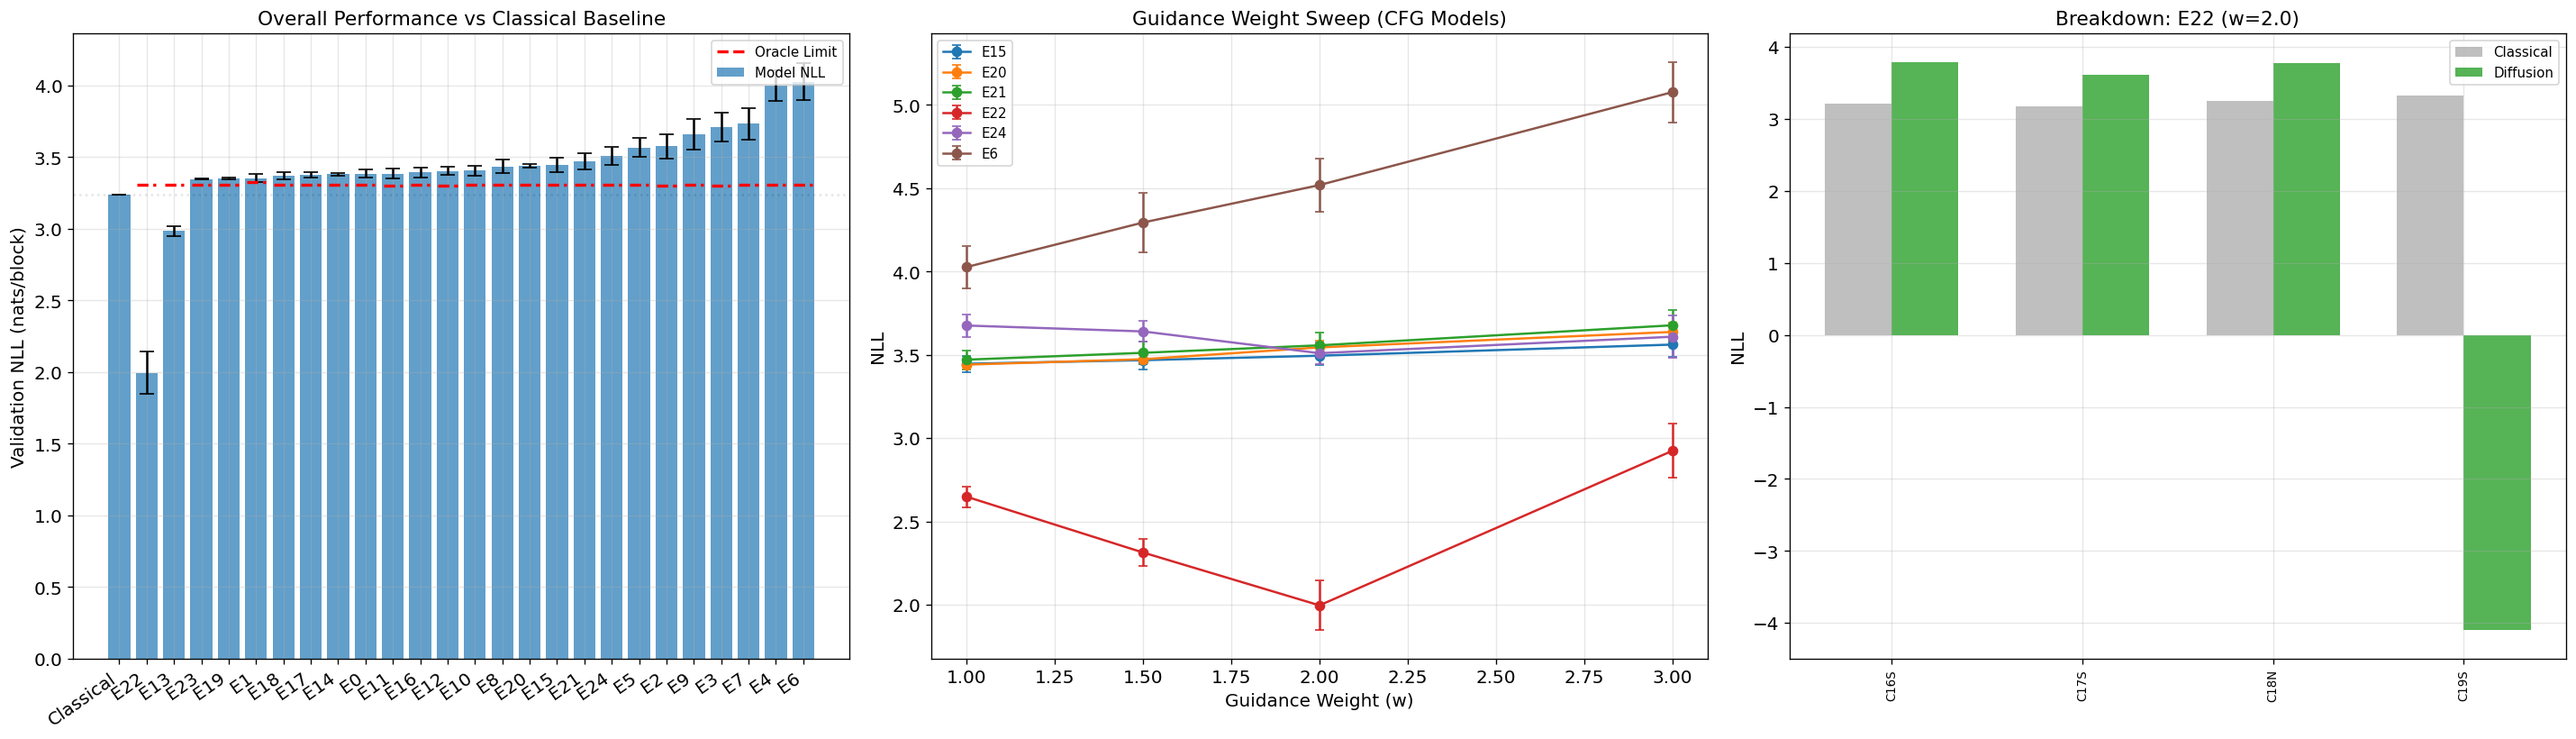

In [210]:
if not EVAL_MODE:
    print("Skipping Task 69 headline plot (MODE=train). Switch MODE to \"eval\" once you have ckpt_E*.ckpt files.")
else:
    # Task 69 — headline plot + CFG sweep + per-hemicycle breakdown.
    #
    # Required panels:
    #   1. Bar chart of val NLL: classical bar on the left, one bar per
    #      experiment (best guidance w if it's a CFG variant), with K-σ
    #      error bars. Overlay each experiment's oracle NLL as a dashed
    #      horizontal marker so the "what's achievable from this cond set"
    #      boundary is visible.
    #   2. (If any CFG checkpoint exists) a sweep of guidance weight vs NLL
    #      on the CFG variant.
    #   3. Per-hemicycle breakdown for the best variant — same axes as the
    #      Week 10 chart so any improvement is visually unambiguous.
    #
    # Useful values you already have:
    #   - `scoreboard` (DataFrame from Task 68)
    #   - `nll_cl_val` (classical baseline)
    #   - `val_hcs`, `EXPERIMENTS`, `K`, `_WEEK10_DIR`
    #
    # For panel 3, reuse `load_trained_experiment(...)`,
    # `block_cond_concat(...)`, `sample_conditional_extended(...)`, and
    # `k_run_combined(...)`.

    # Task 69 — headline plot + CFG sweep + per-hemicycle breakdown.

    # 1. Identify the best performing guidance weight for each experiment
    # We pick the minimum NLL for each experiment name (handling CFG sweeps)
    best_idx = scoreboard.groupby("experiment")["nll_mean"].idxmin()
    best_rows = scoreboard.loc[best_idx].sort_values("nll_mean")

    fig, axes = plt.subplots(1, 3, figsize=(24, 7))

    # --- Panel 1: Bar Chart of Validation NLL ---
    ax = axes[0]
    names = ["Classical"] + best_rows["experiment"].tolist()
    means = [nll_cl_val] + best_rows["nll_mean"].tolist()
    stds  = [0.0] + best_rows["nll_std"].tolist()
    oracles = [np.nan] + best_rows["oracle_nll_mean"].tolist()

    x_pos = np.arange(len(names))
    ax.bar(x_pos, means, yerr=stds, capsize=5, color="C0", alpha=0.7, label="Model NLL")

    # Overlay Oracle NLL as horizontal dashed markers
    # This represents the theoretical limit for each conditioning set
    for i, o in enumerate(oracles):
        if not np.isnan(o):
            ax.hlines(o, i - 0.35, i + 0.35, colors="red", linestyles="--", lw=2, 
                    label="Oracle Limit" if i == 1 else "")

    ax.set_xticks(x_pos)
    ax.set_xticklabels(names, rotation=35, ha="right")
    ax.set_ylabel("Validation NLL (nats/block)")
    ax.set_title("Overall Performance vs Classical Baseline")
    ax.axhline(nll_cl_val, color="black", alpha=0.1, linestyle=":")
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=9, loc='upper right')

    # --- Panel 2: Guidance Weight Sweep (CFG Variants) ---
    ax = axes[1]
    has_cfg_sweep = False
    # We look for experiments that have more than one entry in the scoreboard (implying a sweep)
    for name, group in scoreboard.groupby("experiment"):
        if len(group) > 1:
            group = group.sort_values("guidance_w")
            ax.errorbar(group["guidance_w"], group["nll_mean"], yerr=group["nll_std"], 
                        marker='o', capsize=3, label=name)
            has_cfg_sweep = True

    if has_cfg_sweep:
        ax.set_xlabel("Guidance Weight (w)")
        ax.set_ylabel("NLL")
        ax.set_title("Guidance Weight Sweep (CFG Models)")
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
    else:
        ax.text(0.5, 0.5, "(No multi-weight CFG variants found)", ha="center", va="center", fontsize=12)

    # --- Panel 3: Per-hemicycle breakdown for the best variant ---
    ax = axes[2]
    # Select the best performing diffusion model from Panel 1
    best_exp = best_rows.iloc[0]
    name, w = best_exp["experiment"], best_exp["guidance_w"]

    # Load experiment artifacts and generate samples
    lit, train_ds, val_ds, total_dim = load_trained_experiment(
        name, EXPERIMENTS[name], windows_aug, CKPT_DIR, alpha_np, sigma_np
    )
    keys, cond_tensor = block_cond_concat(val_hcs, lit, EXPERIMENTS[name], train_ds)

    # Generate K samples per block to estimate HC-level NLL
    all_samples = []
    for _ in range(K):
        all_samples.append(sample_conditional_extended(lit, cond_tensor, guidance_w=w).cpu().numpy())
    samples_NK15 = np.stack(all_samples, axis=1) # (N_blocks, K, 15)

    hc_labels = []
    cl_nlls = []
    diff_nlls = []

    for hc in val_hcs:
        cyc, hemi = hc["cycle"], hc["hemisphere"]
        label = f"C{cyc}{hemi[0].upper()}"
        hc_labels.append(label)
        
        # Filter block keys belonging to this hemicycle
        hc_keys = [k for k in keys if k[0] == cyc and k[1] == hemi]
        
        # Calculate Classical NLL for this HC (residuals = 0)
        nll_cl, _ = hard_nll_combined(classical, [hc], {k: np.zeros(15) for k in hc_keys})
        cl_nlls.append(nll_cl)
        
        # Calculate Diffusion NLL for this HC (mean across K paths)
        path_nlls = []
        for k in range(K):
            # Build residual dictionary for this specific path k
            rbb = {keys[i]: samples_NK15[i, k] for i, key in enumerate(keys) if key[0] == cyc and key[1] == hemi}
            nll_diff_path, _ = hard_nll_combined(classical, [hc], rbb)
            path_nlls.append(nll_diff_path)
        diff_nlls.append(np.mean(path_nlls))

    # Grouped bar chart via matplotlib
    x = np.arange(len(hc_labels))
    width = 0.35
    ax.bar(x - width/2, cl_nlls, width, label="Classical", color="gray", alpha=0.5)
    ax.bar(x + width/2, diff_nlls, width, label="Diffusion", color="C2", alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(hc_labels, rotation=90, fontsize=8)
    ax.set_title(f"Breakdown: {name} (w={w})")
    ax.set_ylabel("NLL")
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()


---
## Task 70 — Going further

Once you've worked through the Level 1–5 escalation menu in 10d and
want to push further, the tiered menu below ranks the next experiments
by expected payoff per unit effort. Discipline still applies: one knob
at a time, log to wandb, add to `EXPERIMENTS` in both 10d and 10e,
then re-run.

**Level 1 — easy wins**
- **Wider/deeper MLP.** Bump `hidden_dim` from 128 to 256, `n_layers`
  from 3 to 5 in the winning experiment's config. If NLL drops, the
  network was capacity-bound — interesting on its own.
- **Longer K at evaluation.** Bump K from 100 to 500 for the winning
  variant — tightens the K-σ error bar and lets you trust smaller
  margins.
- **Sampler comparison.** Re-score the winner with DDPM (stochastic)
  sampling instead of the deterministic DDIM in
  `sample_conditional_extended`. Deterministic samplers can under-
  disperse, inflating NLL.

**Level 2 — extra cond information**
- **Larger trajectory K.** Bump `K_LAGS` from 4 to 8 in 10d. If the
  trajectory variant's oracle improves but its diffusion doesn't, the
  architecture is underusing the longer history.
- **Lagged opposite-hemisphere.** Pair the trajectory cond with the
  opposite hemisphere — `opp_area_smoothed_lag1..lag4`.

**Level 3 — architectural changes**
- **Cross-attention conditioning.** Replace the FiLM mechanism with
  cross-attention over a small set of learned cond tokens — overkill
  for the cond dim here, but worth knowing if the FiLM gain saturates.
- **Per-bin-aware loss.** Weight the ε-prediction loss by the inverse
  per-bin std so well-resolved bins don't dominate gradients.

**The test set is the PI's.** Every iteration above is val-only. The
final test-set reveal happens once, after the program is closed.

---
## Handoff back to the PI

The headline numbers in `scoreboard` answer two questions:

1. **Does any variant beat the classical baseline on val?** If yes, the
   diffusion approach has earned its place in the final pipeline.
2. **Where is the bottleneck — information or architecture?** Compare
   each row's `nll_mean` to its `oracle_nll_mean`. A large gap means
   the cond set has more information than the diffusion is extracting
   (architecture-bound). A small gap with the oracle near classical
   means the cond set isn't carrying enough information — that line of
   experiments is exhausted; try a different cond group.

The PI will run the test set evaluation on whatever variant the val
results recommend.
